# Assignment: Video Quality Inference

To this point in the class, you have learned various techniques for leading and analyzing packet captures of various types, generating features from those packet captures, and training and evaluating models using those features.

In this assignment, you will put all of this together, using a network traffic trace to train a model to automatically infer video quality of experience from a labeled traffic trace.

## Part 1: Warmup

The first part of this assignment builds directly on the hands-on activities but extends them slightly.

### Extract Features from the Network Traffic

Load the `netflix.pcap` file, which is a packet trace that includes network traffic.


This copy completes all three parts. Run the cells in order.
If needed, install the packages with `%pip install netml pandas matplotlib scikit-learn`
in a separate cell.

If pandas prints a NumPy compatibility warning, run
`%pip install --upgrade numexpr bottleneck`, then restart the kernel.


In [2]:
import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from netml.pparser.parser import PCAP
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
master_pcap = PCAP("/Users/winstonli/Desktop/ml-systems/docs/notebooks/data/netflix.pcap")
master_pcap.pcap2pandas()
master_df = master_pcap.df


### Identifying the Service Type

Use the DNS traffic to filter the packet trace for Netflix traffic.


In [ ]:
netflix_dns = master_df[
    master_df["dns_query"].astype(str).str.contains("netflix|nflx", case=False)
]

netflix_ips = netflix_dns["dns_resp"].dropna().str[0].unique()

# Keep packets going to OR coming from a Netflix server.
master_df = master_df[
    master_df["ip_src"].isin(netflix_ips) | master_df["ip_dst"].isin(netflix_ips)
].copy()
master_df["time"] = master_df["time"].astype(float)
master_df = master_df.sort_values("time")
print(f"Netflix server addresses: {len(netflix_ips)}; packets: {len(master_df):,}")
master_df.head()


Netflix server addresses: 15; packets: 138,633


,datetime,dns_query,dns_resp,ip_dst,ip_dst_int,ip_src,ip_src_int,is_dns,length,mac_dst,mac_dst_int,mac_src,mac_src_int,port_dst,port_src,protocol,time,time_normed
107,2018-02-11 15:10:02,None,None,198.38.120.130,3.324410e+09,192.168.43.72,3.232247e+09,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58451.0,TCP,1.518358e+09,2.368591
109,2018-02-11 15:10:02,None,None,198.38.120.130,3.324410e+09,192.168.43.72,3.232247e+09,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58452.0,TCP,1.518358e+09,2.368637
110,2018-02-11 15:10:02,None,None,198.38.120.130,3.324410e+09,192.168.43.72,3.232247e+09,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58453.0,TCP,1.518358e+09,2.368733
112,2018-02-11 15:10:02,None,None,52.19.39.146,8.736705e+08,192.168.43.72,3.232247e+09,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58454.0,TCP,1.518358e+09,2.368943
113,2018-02-11 15:10:02,None,None,52.19.39.146,8.736705e+08,192.168.43.72,3.232247e+09,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443.0,58455.0,TCP,1.518358e+09,2.369006


### Generate Statistics

Generate statistics and features for the Netflix traffic flows. Use the netml library or any other technique that you choose to generate a set of features that you think would be good features for your model.


In [ ]:
master_pcap.pcap2flows()
master_pcap.flows = [
    (flow, packets) for flow, packets in master_pcap.flows
    if flow[0] in netflix_ips or flow[1] in netflix_ips
]
master_pcap.flow2features("STATS", fft=False, header=False)

stats_df = pd.DataFrame(master_pcap.features, columns=[
    "duration", "packet_rate", "byte_rate", "size_mean", "size_std",
    "size_q1", "size_median", "size_q3", "size_min", "size_max",
    "packet_count", "byte_count",
])
stats_df["flow"] = master_pcap.fids

iat_summaries = []
for flow, packets in master_pcap.flows:
    times = pd.Series([float(packet.time) for packet in packets])
    iats = times.diff().dropna()
    iat_summaries.append(iats.quantile([0, 0.25, 0.5, 0.75, 1]).tolist())

stats_df[["iat_min", "iat_q1", "iat_median", "iat_q3", "iat_max"]] = pd.DataFrame(
    iat_summaries, index=stats_df.index
)
stats_df.head()


,duration,packet_rate,byte_rate,size_mean,size_std,size_q1,size_median,size_q3,size_min,size_max,packet_count,byte_count,flow,iat_min,iat_q1,iat_median,iat_q3,iat_max
0,14.440177,0.831015,73.683308,88.666667,48.140997,66.0,66.0,69.0,66.0,200.0,12.0,1064.0,"(192.168.43.72, 198.38.120.130, 58451, 443, 6)",0.000158,0.001831,0.557696,1.288490,7.958562
1,14.442865,0.761622,69.099863,90.727273,49.772374,66.0,66.0,72.0,66.0,200.0,11.0,998.0,"(192.168.43.72, 198.38.120.130, 58452, 443, 6)",0.000191,0.002130,0.289165,1.143525,9.313323
2,14.437420,0.831173,73.697377,88.666667,48.140997,66.0,66.0,69.0,66.0,200.0,12.0,1064.0,"(192.168.43.72, 198.38.120.130, 58453, 443, 6)",0.000234,0.001997,0.555151,1.276929,7.973116
3,138.854511,1.497971,184.560082,123.206731,66.443951,66.0,66.0,200.0,54.0,200.0,208.0,25627.0,"(192.168.43.72, 52.19.39.146, 58454, 443, 6)",0.000000,0.000242,0.030390,0.105446,49.886644
4,74.817607,0.360878,45.203263,125.259259,66.350692,66.0,66.0,200.0,54.0,200.0,27.0,3382.0,"(192.168.43.72, 52.19.39.146, 58455, 443, 6)",0.000000,0.000112,0.209720,1.146302,46.446035


In [ ]:
master_df["seconds"] = master_df["time"] - master_df["time"].min()
master_df["window"] = (master_df["seconds"] // 10).astype(int) * 10
window_features = master_df.groupby("window").agg(
    packet_count=("length", "size"),
    captured_bytes=("length", "sum"),
    mean_captured_size=("length", "mean"),
)

window_features = window_features.reindex(
    range(0, int(master_df["window"].max()) + 10, 10), fill_value=0
)
window_features.head()


,packet_count,captured_bytes,mean_captured_size
window,,,
0,571,69986,122.567426
10,558,71430,128.010753
20,552,78803,142.759058
30,454,65227,143.671806
40,441,64080,145.306122


**Write a brief justification for the features that you have chosen.**


I use NetML's 12 STATS features for each flow. Packet count and packet rate describe
how much activity there is. Duration describes how long the flow lasts. Packet-size
statistics describe the sizes and variation of the captured packets. Byte count and
byte rate summarize their captured volume. These features all might be useful as they can
encapsulate the different approaches Netflix might utilize to optimizing video quality
(e.g. Streaming in lower quality video to save bandwidth, trying different servers, different kinds of buffering etc,)

I also add five IAT features: minimum, 25th percentile, median, 75th percentile,
and maximum time between consecutive packets, in seconds. They describe bursts and
pauses within each flow. This might help us understand whether or not the buffers had
the opportunity to work properly or not.


### Inferring Segment downloads

In addition to the features that you could generate using the `netml` library or similar, add to your feature vector a "segment downloads rate" feature, which indicates the number of video segments downloaded for a given time window.

Note: If you are using the `netml` library, generating features with `SAMP` style options may be useful, as this option gives you time windows, and you can then simply add the segment download rate to that existing dataframe.


In [ ]:
# skip small packets.
video_ips = netflix_dns.loc[
    netflix_dns["dns_query"].astype(str).str.contains("nflxvideo"), "dns_resp"
].dropna().str[0].unique()
downloads = master_df[
    master_df["ip_src"].isin(video_ips) &
    (master_df["protocol"] == "TCP") & (master_df["length"] >= 200)
].copy()

# Estimate a new segment when a connection pauses for more than 0.5 seconds.
flow_columns = ["ip_src", "ip_dst", "port_src", "port_dst"]
gaps = downloads.groupby(flow_columns)["time"].diff()
downloads["new_segment"] = gaps.isna() | (gaps > 0.5)
segment_counts = downloads.groupby("window")["new_segment"].sum()
window_features["segment_downloads"] = segment_counts.reindex(
    window_features.index, fill_value=0
)
window_features["segment_download_rate"] = window_features["segment_downloads"] / 10
window_features.head(10)


,packet_count,captured_bytes,mean_captured_size,segment_downloads,segment_download_rate
window,,,,,
0,571,69986,122.567426,26,2.6
10,558,71430,128.010753,6,0.6
20,552,78803,142.759058,14,1.4
30,454,65227,143.671806,15,1.5
40,441,64080,145.306122,10,1.0
50,2819,412202,146.222774,9,0.9
60,19757,2981863,150.926912,6,0.6
70,18208,2772133,152.248078,0,0.0
80,1983,293996,148.258195,11,1.1


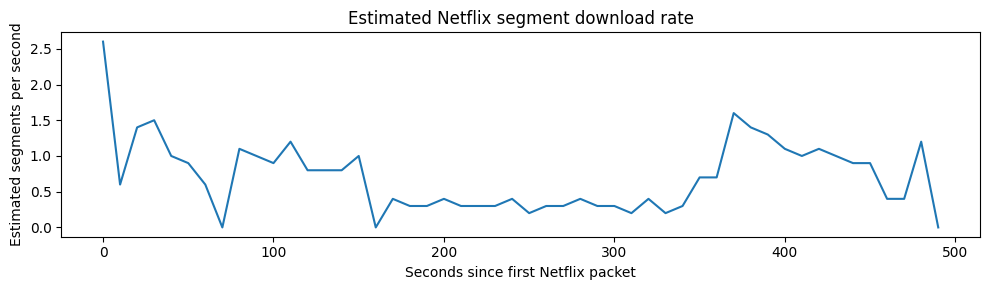

In [8]:
window_features["segment_download_rate"].plot(figsize=(10, 3))
plt.xlabel("Seconds since first Netflix packet")
plt.ylabel("Estimated segments per second")
plt.title("Estimated Netflix segment download rate")
plt.tight_layout()
plt.show()


## Part 2: Video Quality Inference

Use the complete study dataset to predict resolution from traffic features.
The working dataset was downloaded from the [course data repository](https://github.com/noise-courses/data/tree/main/video-qoe)
and decompressed into `data/video_dataset.pkl` beside this notebook.

The old Google Drive links no longer work. The replacement `netflix_session.pkl` also contains
an HTML error page. For Part 3, we instead reserve the first real Netflix session from the
working dataset **before splitting or training**. It is a replacement for the unavailable file.


### Load the File

Load the video dataset pickle file.

In [2]:
import numpy as np

data_folder = "/Users/winstonli/Desktop/ml-systems/docs/assignments/data/"
video = pd.read_pickle(data_folder + "video_dataset.pkl")
print("Original dataset:", video.shape)

# Set aside one complete Netflix session for Part 3.
session_id = video.loc[video["service"] == "netflix", "session_id"].iloc[0]
netflix_session = video[video["session_id"] == session_id].copy()
video = video[video["session_id"] != session_id].copy()
print("Reserved Netflix session:", session_id)
print("Reserved windows:", len(netflix_session))
video.head()


Original dataset: (204713, 170)
Reserved Netflix session: 7ff91b2519956acd8d59932235005743
Reserved windows: 61


,L7_10_avg_chunksize,L7_10_chunksizes_50,L7_10_chunksizes_75,L7_10_chunksizes_85,L7_10_chunksizes_90,L7_10_max_chunksize,L7_10_min_chunksize,L7_10_std_chunksize,absolute_timestamp,L7_all_prev_down_chunk_iat_50,...,L4_userStdRTT,L4_userStdRetransmit,L4_userStdRwnd,L4_userStrBytesInFlight,L4_userSynFlags,L4_userTwoRetransmit,L4_userUrgFlags,L4_userXRetransmit,L4_userZeroRetransmit,service
61,499543.4,561033.0,663360.0,685442.0,688700.2,695218,195654,185221.299086,1.517805e+09,118.5,...,19896.182658,404.498377,1997.169343,0,5,0.0,0,0.045247,0.402122,netflix
62,539509.0,667462.0,705231.5,707234.4,713268.0,758448,195178,228404.733494,1.517805e+09,132.0,...,11342.837296,570.797599,803.137387,696,0,0.0,0,0.016082,0.141813,netflix
63,518127.2,590719.0,701249.5,707234.4,709696.0,722728,195178,216439.317214,1.517805e+09,142.0,...,522.874512,86.133617,854.267579,0,0,0.0,0,0.039474,0.065789,netflix
64,517982.0,586375.0,665412.5,699608.5,707089.6,722728,195178,184161.977016,1.517805e+09,143.0,...,48.095703,200.818326,179.463374,0,0,0.0,0,0.017544,0.035088,netflix
65,495006.6,577687.0,586615.5,596657.2,614130.4,722728,196624,166467.487586,1.517805e+09,149.0,...,330.745429,178.042416,698.996355,0,0,0.0,0,0.039474,0.118421,netflix


### Clean the File

1. The dataset contains video resolutions that are not valid. Remove entries in the dataset that do not contain a valid video resolution. Valid resolutions are 240, 360, 480, 720, 1080.

In [3]:
valid_resolutions = [240, 360, 480, 720, 1080]
before = len(video)
video = video[video["resolution"].isin(valid_resolutions)].copy()
video["resolution"] = video["resolution"].astype(int)
print("Invalid rows removed:", before - len(video))
video["resolution"].value_counts().sort_index()


Invalid rows removed: 4647


resolution
240     45538
360     31709
480     73046
720     37942
1080    11770
Name: count, dtype: int64

2. The file also contains columns that are unnecessary (in fact, unhelpful!) for performing predictions. Identify those columns, and remove them.

In [ ]:
# Keep the label separate and remove identifiers and playback metadata.
y = video["resolution"]
traffic_data = video.drop(columns=[
    "resolution", "home_id", "session_id", "video_id", "index",
    "absolute_timestamp", "relative_timestamp", "video_position", "service",
])
traffic_data["segment_download_rate"] = traffic_data["L7_n_chunks_down"] / 10
traffic_data = traffic_data.drop(columns="L7_n_chunks_down")  # Same information as the rate.
X = traffic_data.replace([np.inf, -np.inf], np.nan)

baseline_features = [
    "L3_service_Video_throughput_down", "L3_service_Video_throughput_up",
    "L3_parallel_flows", "L3_serverPacketCount",
    "L7_10_avg_chunksize", "L7_10_std_chunksize",
    "L7_down_chunk_iat_avg", "segment_download_rate",
]
transport_features = [
    "L4_userAvgRTT", "L4_serverAvgRetransmit",
    "L4_serverAvgBytesInFlight", "L4_serverAvgBytesPerPacket",
]
chunk_features = ["L7_10_chunksizes_90", "L7_down_chunk_iat_std"]
feature_sets = {
    "Baseline": baseline_features,
    "Baseline + transport": baseline_features + transport_features,
    "Baseline + chunk detail": baseline_features + chunk_features,
    "Combined": baseline_features + transport_features + chunk_features,
    "All traffic": X.columns.tolist(),
}
pd.Series({name: len(columns) for name, columns in feature_sets.items()}, name="Features")


Baseline                     8
Baseline + transport        12
Baseline + chunk detail     10
Combined                    14
All traffic                161
Name: Features, dtype: int64

**Briefly explain why you removed those columns.**

resolution is the answer, so it cannot be an input. home_id, session_id, video_id,
and index identify recordings or records and could encourage memorization. Timestamps and
video_position describe the recording or playback position. I keep time only for the Part 3 plot.
I remove service so predictions use traffic measurements rather than the service name.

We compare five feature sets instead of assuming more features must help:

- **Baseline (8):** our original throughput, packet count, flow count, and chunk features.
- **Baseline + transport (12):** adds average RTT, retransmissions, bytes in flight, and packet size.
- **Baseline + chunk detail (10):** adds the 90th-percentile chunk size and variation in chunk IAT.
- **Combined (14):** adds both groups.
- **All traffic (161):** uses every remaining traffic measurement.

Segment download rate is the provided 10-second chunk count divided by 10. We remove the
original count because it contains the same information. Part 1's flow statistics remain
separate: these supplied window features already have matching resolution labels.


### Prepare Your Data

Prepare your data matrix, determine your features and labels, and perform a train-test split on your data.

In [5]:
from sklearn.model_selection import train_test_split, GroupKFold, GridSearchCV, cross_validate

# Split session IDs, then keep all rows from each session together.
train_ids, test_ids = train_test_split(
    video["session_id"].unique(), test_size=0.2, random_state=42
)
train_mask = video["session_id"].isin(train_ids)
test_mask = video["session_id"].isin(test_ids)
X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]
train_groups = video.loc[train_mask, "session_id"]
cv = GroupKFold(n_splits=3)

assert set(train_ids).isdisjoint(test_ids)
print(f"Training: {len(X_train):,} rows from {len(train_ids):,} sessions")
print(f"Test: {len(X_test):,} rows from {len(test_ids):,} sessions")
print("Sessions shared between training and test:", len(set(train_ids) & set(test_ids)))


Training: 160,099 rows from 3,196 sessions
Test: 39,906 rows from 799 sessions
Sessions shared between training and test: 0


### Train and Tune Your Model

1. Select a model of your choice.
2. Train the model using your training data.

In [6]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Use identical forest settings and the same three session-separated folds for every feature set.
model = make_pipeline(
    SimpleImputer(strategy="median"),
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
)
comparison_rows = []
for name, columns in feature_sets.items():
    results = cross_validate(
        model, X_train[columns], y_train, cv=cv, groups=train_groups,
        scoring={"accuracy": "accuracy", "f1": "f1_macro"},
        return_train_score=True,
    )
    comparison_rows.append({
        "Feature set": name,
        "Features": len(columns),
        "Training accuracy": results["train_accuracy"].mean(),
        "CV accuracy": results["test_accuracy"].mean(),
        "CV macro F1": results["test_f1"].mean(),
        "F1 fold std": results["test_f1"].std(),
    })
    print(f"{name}: CV macro F1 = {results['test_f1'].mean():.3f}")

comparison = pd.DataFrame(comparison_rows).sort_values("CV macro F1", ascending=False)
comparison.to_csv(data_folder + "feature_set_comparison.csv", index=False)
comparison.round(4)


Baseline: CV macro F1 = 0.793


Baseline + transport: CV macro F1 = 0.809


Baseline + chunk detail: CV macro F1 = 0.813


Combined: CV macro F1 = 0.822


All traffic: CV macro F1 = 0.894


,Feature set,Features,Training accuracy,CV accuracy,CV macro F1,F1 fold std
4,All traffic,161,1.0000,0.9034,0.8943,0.0069
3,Combined,14,0.9999,0.8309,0.8219,0.0017
2,Baseline + chunk detail,10,0.9999,0.8275,0.8127,0.0055
1,Baseline + transport,12,0.9999,0.8198,0.8087,0.0023
0,Baseline,8,0.9999,0.8096,0.7930,0.0072


Each feature set uses the same 100-tree random forest, training rows, and three validation
folds. GroupKFold keeps whole sessions together, so a validation session never appears in
that fold's training data. Median imputation is fitted inside each training fold.

The table shows mean training accuracy, validation accuracy, and validation macro F1.
The last column shows variation in F1 across the three folds, not a confidence interval.
I select the feature set with the highest validation macro F1, then try four forest settings
using the same session-separated folds. Selection scores may be optimistic because they
were used to choose the winner. Only the selected model is evaluated on the test sessions.

The outer split still uses train_test_split, applied to unique session IDs instead of rows.
No session appears in both training and test data. The separate Part 3 session stays excluded
from both sets and from all feature selection and tuning.

**Results:** 3,196 sessions are used for training and 799 for testing, with zero shared sessions. Zero overlap was also verified in every validation fold. All 161 traffic features won, with validation macro F1 0.894.


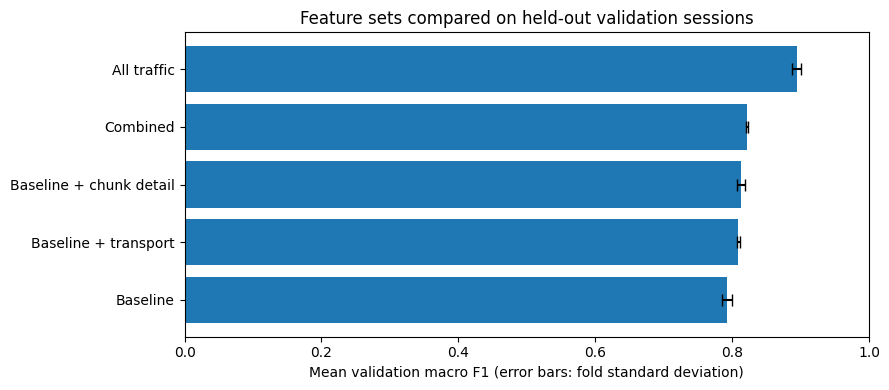

In [7]:
plot_data = comparison.sort_values("CV macro F1")
plt.figure(figsize=(9, 4))
plt.barh(plot_data["Feature set"], plot_data["CV macro F1"],
         xerr=plot_data["F1 fold std"], capsize=4)
plt.xlim(0, 1)
plt.xlabel("Mean validation macro F1 (error bars: fold standard deviation)")
plt.title("Feature sets compared on held-out validation sessions")
plt.tight_layout()
plt.show()


### Tune Your Model

Perform hyperparameter tuning to find optimal parameters for your model.

In [8]:
# Select the feature set using validation scores, then tune that set's forest.
best_set = comparison.iloc[0]["Feature set"]
feature_columns = feature_sets[best_set]
X_train = X_train[feature_columns]
X_test = X_test[feature_columns]

parameters = {
    "randomforestclassifier__max_depth": [10, None],
    "randomforestclassifier__min_samples_leaf": [1, 5],
}
search = GridSearchCV(model, parameters, scoring="f1_macro", cv=cv)
search.fit(X_train, y_train, groups=train_groups)
best_model = search.best_estimator_
print("Selected feature set:", best_set)
print("Best settings:", search.best_params_)
print(f"Tuned cross-validation macro F1: {search.best_score_:.3f}")


Selected feature set: All traffic
Best settings: {'randomforestclassifier__max_depth': None, 'randomforestclassifier__min_samples_leaf': 1}
Tuned cross-validation macro F1: 0.894


### Evaluate Your Model

Evaluate your model accuracy according to the following metrics:

1. Accuracy
2. F1 Score
3. Confusion Matrix
4. ROC/AUC

Accuracy         0.9548
Macro F1         0.9535
Weighted F1      0.9547
Macro ROC AUC    0.9971
Majority-class baseline accuracy: 0.365


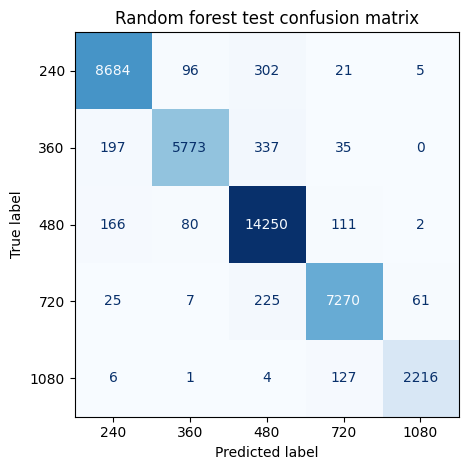

In [31]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay

predictions = best_model.predict(X_test)
probabilities = best_model.predict_proba(X_test)
classes = best_model.classes_

scores = pd.Series({
    "Accuracy": accuracy_score(y_test, predictions),
    "Macro F1": f1_score(y_test, predictions, average="macro"),
    "Weighted F1": f1_score(y_test, predictions, average="weighted"),
    "Macro ROC AUC": roc_auc_score(
        y_test, probabilities, labels=classes, multi_class="ovr", average="macro"
    ),
})
print(scores.round(4).to_string())
print(f"Majority-class baseline accuracy: {(y_test == y_train.mode()[0]).mean():.3f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, predictions, labels=classes, cmap="Blues", colorbar=False
)
plt.title("Random forest test confusion matrix")
plt.tight_layout()
plt.show()


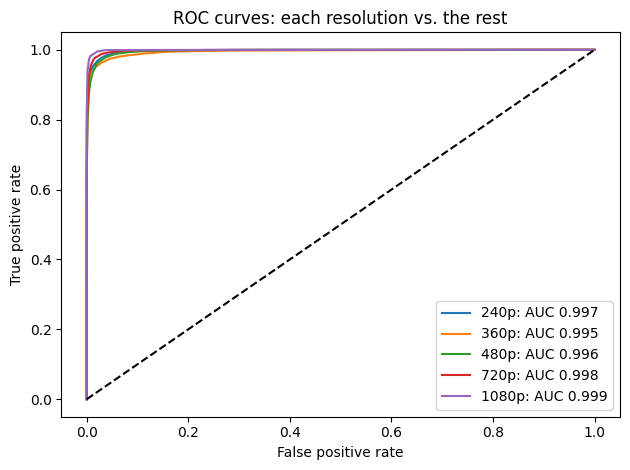

In [32]:
from sklearn.metrics import roc_curve, auc

for i, resolution in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test == resolution, probabilities[:, i])
    plt.plot(fpr, tpr, label=f"{resolution}p: AUC {auc(fpr, tpr):.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves: each resolution vs. the rest")
plt.legend()
plt.tight_layout()
plt.show()


## Part 3: Predict the Ongoing Resolution of a Real Netflix Session

Now that you have your model, it's time to put it in practice!

Use a preprocessed Netflix video session to infer **and plot** the resolution at 10-second time intervals.

In [33]:
# This real Netflix session was excluded from all training and tuning.
session = netflix_session.sort_values("relative_timestamp").copy()
session["segment_download_rate"] = session["L7_n_chunks_down"] / 10
session_X = session[feature_columns].replace([np.inf, -np.inf], np.nan)

session_results = pd.DataFrame({
    "seconds": session["relative_timestamp"].to_numpy(),
    "predicted_resolution": best_model.predict(session_X),
    "actual_resolution": session["resolution"].where(
        session["resolution"].isin(valid_resolutions)
    ).to_numpy(),
})
session_results.to_csv(data_folder + "netflix_session_predictions.csv", index=False)
session_results.head(12)


,seconds,predicted_resolution,actual_resolution
0,10.0,480,360.0
1,20.0,240,360.0
2,30.0,240,360.0
3,40.0,240,360.0
4,50.0,480,480.0
5,60.0,480,480.0
6,70.0,480,480.0
7,80.0,480,480.0
8,90.0,480,480.0
9,100.0,480,480.0


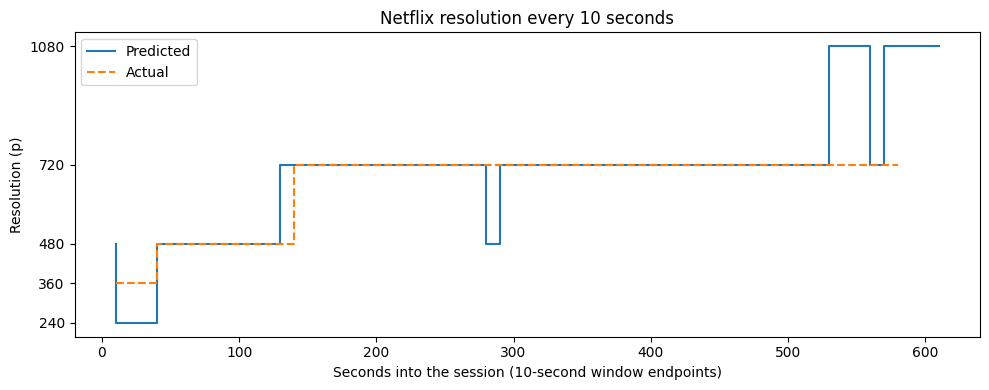

Predicted 61 windows; 58 have valid actual labels.
Session accuracy on valid labels: 0.828


In [34]:
plt.figure(figsize=(10, 4))
plt.step(session_results["seconds"], session_results["predicted_resolution"],
         where="pre", label="Predicted")
plt.step(session_results["seconds"], session_results["actual_resolution"],
         where="pre", label="Actual", linestyle="--")
plt.yticks(valid_resolutions)
plt.xlabel("Seconds into the session (10-second window endpoints)")
plt.ylabel("Resolution (p)")
plt.title("Netflix resolution every 10 seconds")
plt.legend()
plt.tight_layout()
plt.show()

known = session_results["actual_resolution"].notna()
session_accuracy = accuracy_score(
    session_results.loc[known, "actual_resolution"],
    session_results.loc[known, "predicted_resolution"],
)
print(f"Predicted {len(session_results)} windows; {known.sum()} have valid actual labels.")
print(f"Session accuracy on valid labels: {session_accuracy:.3f}")
